# Offline training — Toronto City hourly weather (Mays 2016–2026)

Predicts next-hour temperature from current hour's features.
Loads every `data/en_climate_hourly_*.csv` via the shared `src.data_loader`, trains a
Linear Regression and a Random Forest, then saves `model.joblib` for the Faust streams app.

Run this notebook from `assignment_1/` so the relative paths resolve.

In [1]:
import sys
sys.path.insert(0, '.')

import joblib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score

from src.data_loader import load_all, FEATURE_ORDER

plt.rcParams['figure.dpi'] = 110

In [2]:
df = load_all()
df['temp_next'] = df['temp'].shift(-1)
df = df.dropna(subset=['temp_next']).reset_index(drop=True)
print(f'rows={len(df)}  ts range: {df.ts.min()} -> {df.ts.max()}')
df.head()

rows=7894  ts range: 2016-05-01 00:00:00 -> 2026-05-20 22:00:00


,ts,hour,temp,dew_point,humidity,pressure,temp_next
0,2016-05-01 00:00:00,0,10.5,-0.8,45.0,100.46,10.7
1,2016-05-01 01:00:00,1,10.7,-0.3,47.0,100.40,9.5
2,2016-05-01 02:00:00,2,9.5,2.7,63.0,100.36,9.2
3,2016-05-01 03:00:00,3,9.2,5.0,75.0,100.31,8.0
4,2016-05-01 04:00:00,4,8.0,5.6,85.0,100.31,7.4


## Temperature overview — Mays 2016–2026

Each line is one year of hourly observations, day-of-May on the x-axis. Year-to-year variability is
noticeable; 2026 (the held-out test year) is highlighted.

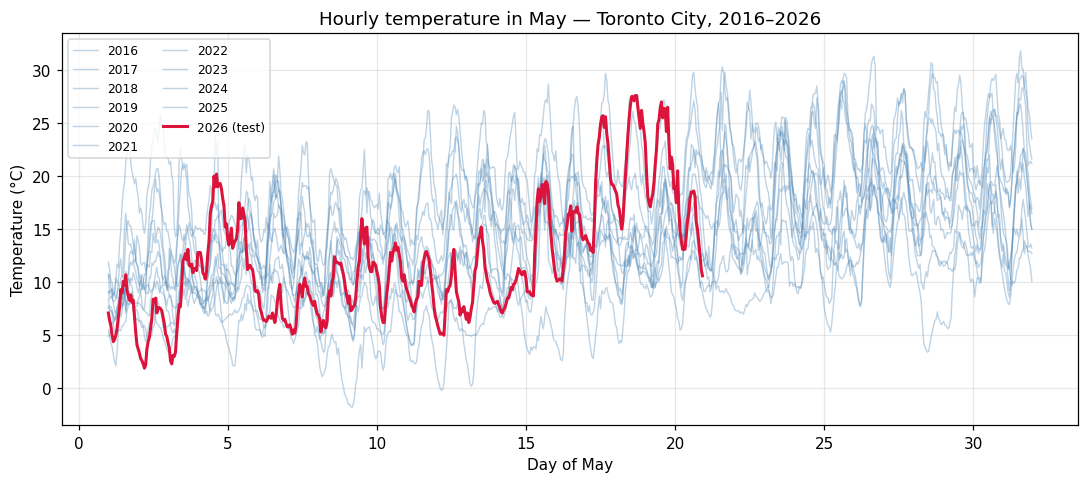

In [3]:
fig, ax = plt.subplots(figsize=(10, 4.5))
test_year = df['ts'].dt.year.max()
for yr, grp in df.groupby(df['ts'].dt.year):
    grp = grp.copy()
    grp['x'] = grp['ts'].dt.day + grp['ts'].dt.hour / 24.0
    if yr == test_year:
        ax.plot(grp['x'], grp['temp'], color='crimson', lw=2.0, label=f'{yr} (test)', zorder=5)
    else:
        ax.plot(grp['x'], grp['temp'], color='steelblue', alpha=0.35, lw=0.9, label=str(yr))
ax.set_title('Hourly temperature in May — Toronto City, 2016–2026')
ax.set_xlabel('Day of May')
ax.set_ylabel('Temperature (°C)')
handles, labels = ax.get_legend_handles_labels()
uniq = dict(zip(labels, handles))
ax.legend(uniq.values(), uniq.keys(), ncol=2, fontsize=8, loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
# Chronological split: hold out the most recent year as the test set.
cutoff = df['ts'].dt.year.max()
test_mask = df['ts'].dt.year == cutoff
train_df = df.loc[~test_mask]
test_df = df.loc[test_mask]

X_train = train_df[FEATURE_ORDER].values
y_train = train_df['temp_next'].values
X_test = test_df[FEATURE_ORDER].values
y_test = test_df['temp_next'].values
temp_now_test = test_df['temp'].values
ts_test = test_df['ts'].values

print(f'train rows={len(X_train)}  test rows={len(X_test)}  test year={cutoff}')

train rows=7415  test rows=479  test year=2026


In [5]:
def evaluate(name, model):
    pred = model.predict(X_test)
    rmse = float(np.sqrt(mean_squared_error(y_test, pred)))
    r2 = float(r2_score(y_test, pred))
    actual_dir = (y_test > temp_now_test).astype(int)
    pred_dir = (pred > temp_now_test).astype(int)
    acc = float(accuracy_score(actual_dir, pred_dir))
    f1 = float(f1_score(actual_dir, pred_dir, zero_division=0))
    print(f'{name:>20} | RMSE={rmse:.3f} R2={r2:.3f} acc={acc:.3f} F1={f1:.3f}')
    return {'name': name, 'rmse': rmse, 'r2': r2, 'accuracy': acc, 'f1': f1, 'pred': pred}

lr = LinearRegression().fit(X_train, y_train)
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1).fit(X_train, y_train)
results = [evaluate('LinearRegression', lr), evaluate('RandomForest', rf)]

    LinearRegression | RMSE=1.037 R2=0.966 acc=0.599 F1=0.549
        RandomForest | RMSE=0.892 R2=0.975 acc=0.731 F1=0.701


## Predicted vs actual — May 2026 (held-out test set)

Top: both models tracked over the test month. Bottom: scatter against the y=x reference line — points
on the line are perfect predictions.

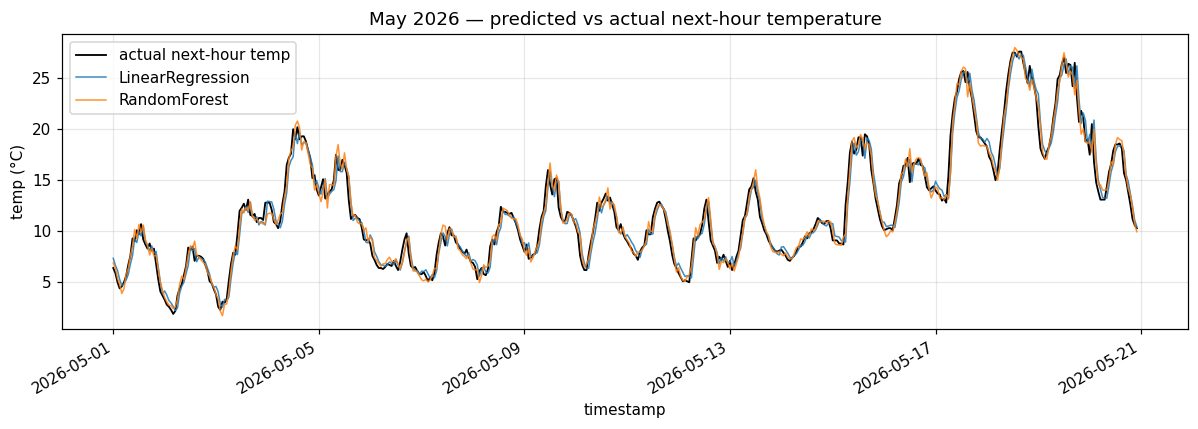

In [6]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(ts_test, y_test, color='black', lw=1.2, label='actual next-hour temp')
ax.plot(ts_test, results[0]['pred'], color='tab:blue', lw=1.0, alpha=0.85, label='LinearRegression')
ax.plot(ts_test, results[1]['pred'], color='tab:orange', lw=1.0, alpha=0.85, label='RandomForest')
ax.set_title(f'May {test_year} — predicted vs actual next-hour temperature')
ax.set_xlabel('timestamp')
ax.set_ylabel('temp (°C)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

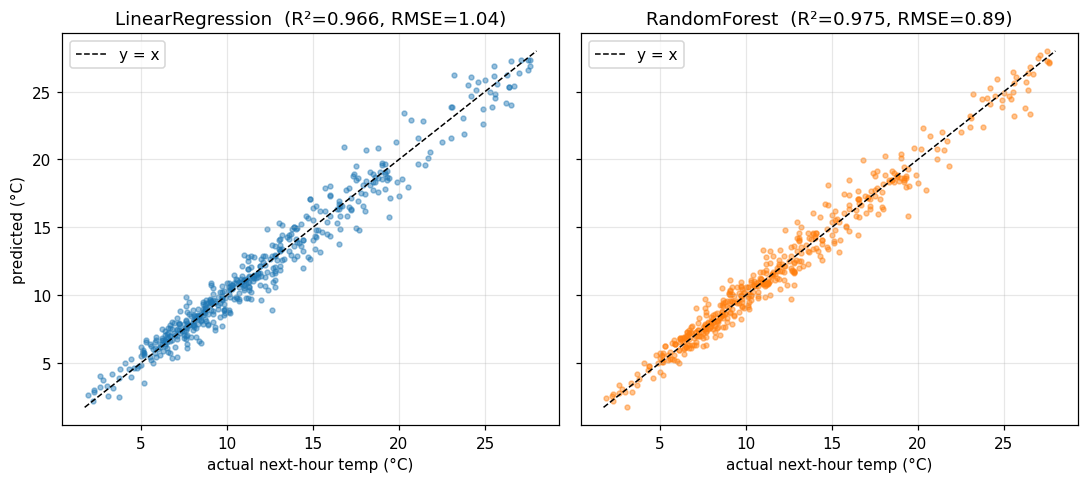

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharex=True, sharey=True)
lo = min(y_test.min(), results[0]['pred'].min(), results[1]['pred'].min())
hi = max(y_test.max(), results[0]['pred'].max(), results[1]['pred'].max())
for ax, r, color in zip(axes, results, ['tab:blue', 'tab:orange']):
    ax.scatter(y_test, r['pred'], s=10, alpha=0.45, color=color)
    ax.plot([lo, hi], [lo, hi], color='black', lw=1, ls='--', label='y = x')
    ax.set_title(f"{r['name']}  (R²={r['r2']:.3f}, RMSE={r['rmse']:.2f})")
    ax.set_xlabel('actual next-hour temp (°C)')
    ax.grid(alpha=0.3)
    ax.legend(loc='upper left')
axes[0].set_ylabel('predicted (°C)')
plt.tight_layout()
plt.show()

## Residuals — Linear Regression (the deployed model)

Distribution of `pred − actual` on the test set. Centered near zero with a tight spread means the model
is not systematically biased.

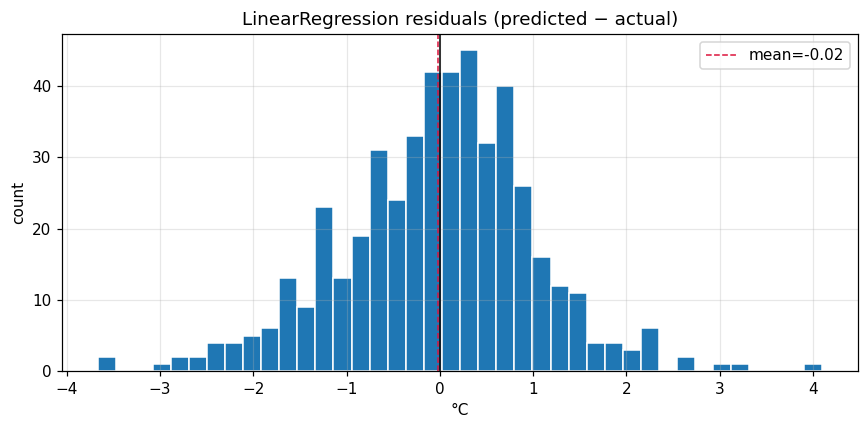

In [8]:
resid = results[0]['pred'] - y_test
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(resid, bins=40, color='tab:blue', edgecolor='white')
ax.axvline(0, color='black', lw=1)
ax.axvline(resid.mean(), color='crimson', lw=1, ls='--', label=f'mean={resid.mean():+.2f}')
ax.set_title('LinearRegression residuals (predicted − actual)')
ax.set_xlabel('°C')
ax.set_ylabel('count')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Metric comparison

RMSE (lower is better) and R² / accuracy / F1 (higher is better) side-by-side.

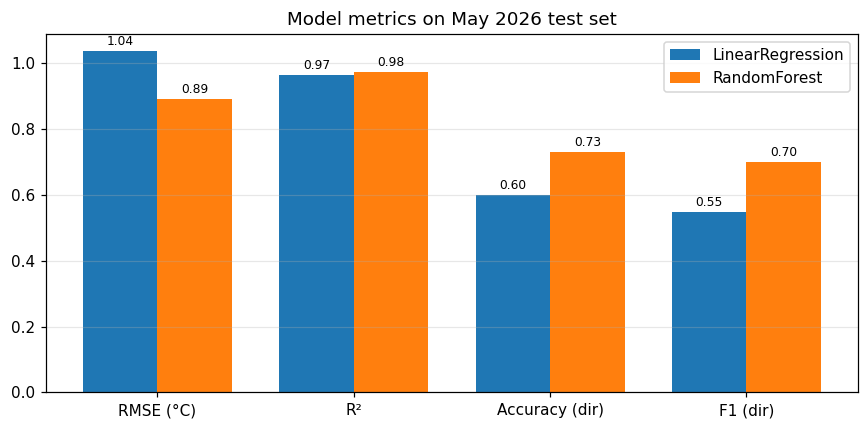

In [9]:
metrics = ['rmse', 'r2', 'accuracy', 'f1']
labels = ['RMSE (°C)', 'R²', 'Accuracy (dir)', 'F1 (dir)']
x = np.arange(len(metrics))
width = 0.38
fig, ax = plt.subplots(figsize=(8, 4))
lr_vals = [results[0][m] for m in metrics]
rf_vals = [results[1][m] for m in metrics]
b1 = ax.bar(x - width/2, lr_vals, width, label='LinearRegression', color='tab:blue')
b2 = ax.bar(x + width/2, rf_vals, width, label='RandomForest', color='tab:orange')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title('Model metrics on May 2026 test set')
ax.bar_label(b1, fmt='%.2f', padding=2, fontsize=8)
ax.bar_label(b2, fmt='%.2f', padding=2, fontsize=8)
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [10]:
# Persist the linear regression model (assignment explicitly mentions linear regression).
joblib.dump(lr, 'model.joblib')
print('Saved model.joblib')
print('Metrics for README:')
for r in results:
    print({k: v for k, v in r.items() if k != 'pred'})

Saved model.joblib
Metrics for README:
{'name': 'LinearRegression', 'rmse': 1.037324962412927, 'r2': 0.9661937617959989, 'accuracy': 0.5991649269311065, 'f1': 0.5492957746478874}
{'name': 'RandomForest', 'rmse': 0.8915570564267334, 'r2': 0.975027301571144, 'accuracy': 0.7306889352818372, 'f1': 0.7006960556844548}
